In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_function = pd.read_excel("../data/01_FunctionAnalysis_data.xlsx")
df_force = pd.read_excel("../data/02_ForceAnalysis_data.xlsx")
df_torque = pd.read_excel("../data/03_TorqueAnalysis_Data.xlsx")
df_torque.rename(columns={"Paciente": "ID"}, inplace=True)

In [4]:
df_total_temp = df_function.merge(df_force, on=["ID", "Gender", "BMI_Value", "AgeGroup", "Clinical Treatment"])

df = df_total_temp.merge(df_torque, on=["ID", "Gender", "BMI_Value", "AgeGroup", "Clinical Treatment"])

df.columns, df.shape

(Index(['ID', 'Gender', 'BMI_Value', 'AgeGroup', 'Clinical Treatment',
        'tSTRIDE', 'tSTANCE', 'tSWING', 'tDBLSTANCE', 'velMEAN', 'fGRVE',
        'fGRAP', 'fGRML', 'fAML', 'fKML', 'fKAP', 'fKCP', 'fHPML', 'fHPAP',
        'fHPCP', 'tGRVE', 'tAFE', 'tKFE', 'tKAA', 'tKIE', 'tHPFE', 'tHPAA',
        'tHPIE'],
       dtype='str'),
 (81, 28))

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  81 non-null     int64  
 1   Gender              81 non-null     str    
 2   BMI_Value           81 non-null     str    
 3   AgeGroup            81 non-null     str    
 4   Clinical Treatment  81 non-null     str    
 5   tSTRIDE             81 non-null     float64
 6   tSTANCE             81 non-null     float64
 7   tSWING              81 non-null     float64
 8   tDBLSTANCE          81 non-null     float64
 9   velMEAN             81 non-null     float64
 10  fGRVE               81 non-null     float64
 11  fGRAP               81 non-null     float64
 12  fGRML               81 non-null     float64
 13  fAML                81 non-null     float64
 14  fKML                81 non-null     float64
 15  fKAP                81 non-null     float64
 16  fKCP                8

In [17]:
categorical_cols = ["ID", "Gender", "BMI_Value", "AgeGroup", "Clinical Treatment"]

numerical_cols = list(set(df.columns) - set(categorical_cols))

In [18]:
df[numerical_cols].describe()

,tSWING,fHPAP,fAML,fKCP,tDBLSTANCE,fGRVE,fKAP,tKFE,velMEAN,fGRAP,...,tSTRIDE,tSTANCE,tHPAA,tGRVE,tHPIE,tKAA,tAFE,fHPCP,fGRML,fHPML
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,...,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,0.440889,-0.893741,1.078457,9.147531,0.156185,99.419852,0.708148,0.095370,0.929173,-7.913914,...,1.178963,0.737556,0.653222,-0.056840,0.044741,0.391494,0.202630,7.762049,4.613864,0.222284
std,0.036216,0.916749,0.383196,0.539429,0.043524,5.430512,0.565171,0.237567,0.203342,3.973958,...,0.115589,0.089332,0.151242,0.226014,0.059240,0.132340,0.161076,0.470937,1.793173,0.463117
min,0.360000,-2.915000,0.260000,7.643000,0.090000,86.897000,-1.292000,-0.592000,0.490000,-18.869000,...,0.940000,0.570000,0.310000,-0.559000,-0.105000,0.132000,-0.136000,6.632000,-0.069000,-1.122000
25%,0.420000,-1.523000,0.839000,8.838000,0.130000,96.027000,0.436000,-0.069000,0.800000,-11.274000,...,1.110000,0.680000,0.566000,-0.223000,0.013000,0.288000,0.093000,7.380000,3.446000,-0.103000
50%,0.440000,-0.825000,1.064000,9.069000,0.150000,98.896000,0.706000,0.129000,0.938000,-7.474000,...,1.160000,0.710000,0.644000,-0.039000,0.048000,0.382000,0.196000,7.743000,4.710000,0.222000
75%,0.470000,-0.297000,1.262000,9.395000,0.170000,101.943000,1.119000,0.247000,1.044000,-4.536000,...,1.240000,0.780000,0.742000,0.105000,0.081000,0.465000,0.270000,8.076000,5.766000,0.612000
max,0.520000,1.237000,2.342000,10.856000,0.340000,117.109000,2.223000,0.562000,1.365000,0.117000,...,1.450000,1.000000,1.039000,0.377000,0.188000,0.855000,0.660000,9.283000,9.051000,1.179000


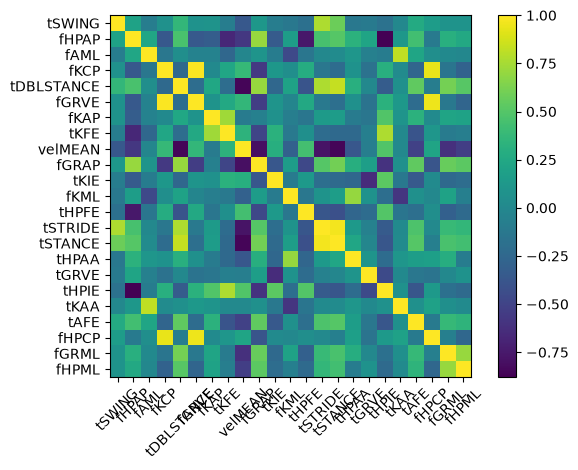

In [21]:
corr = df[numerical_cols].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

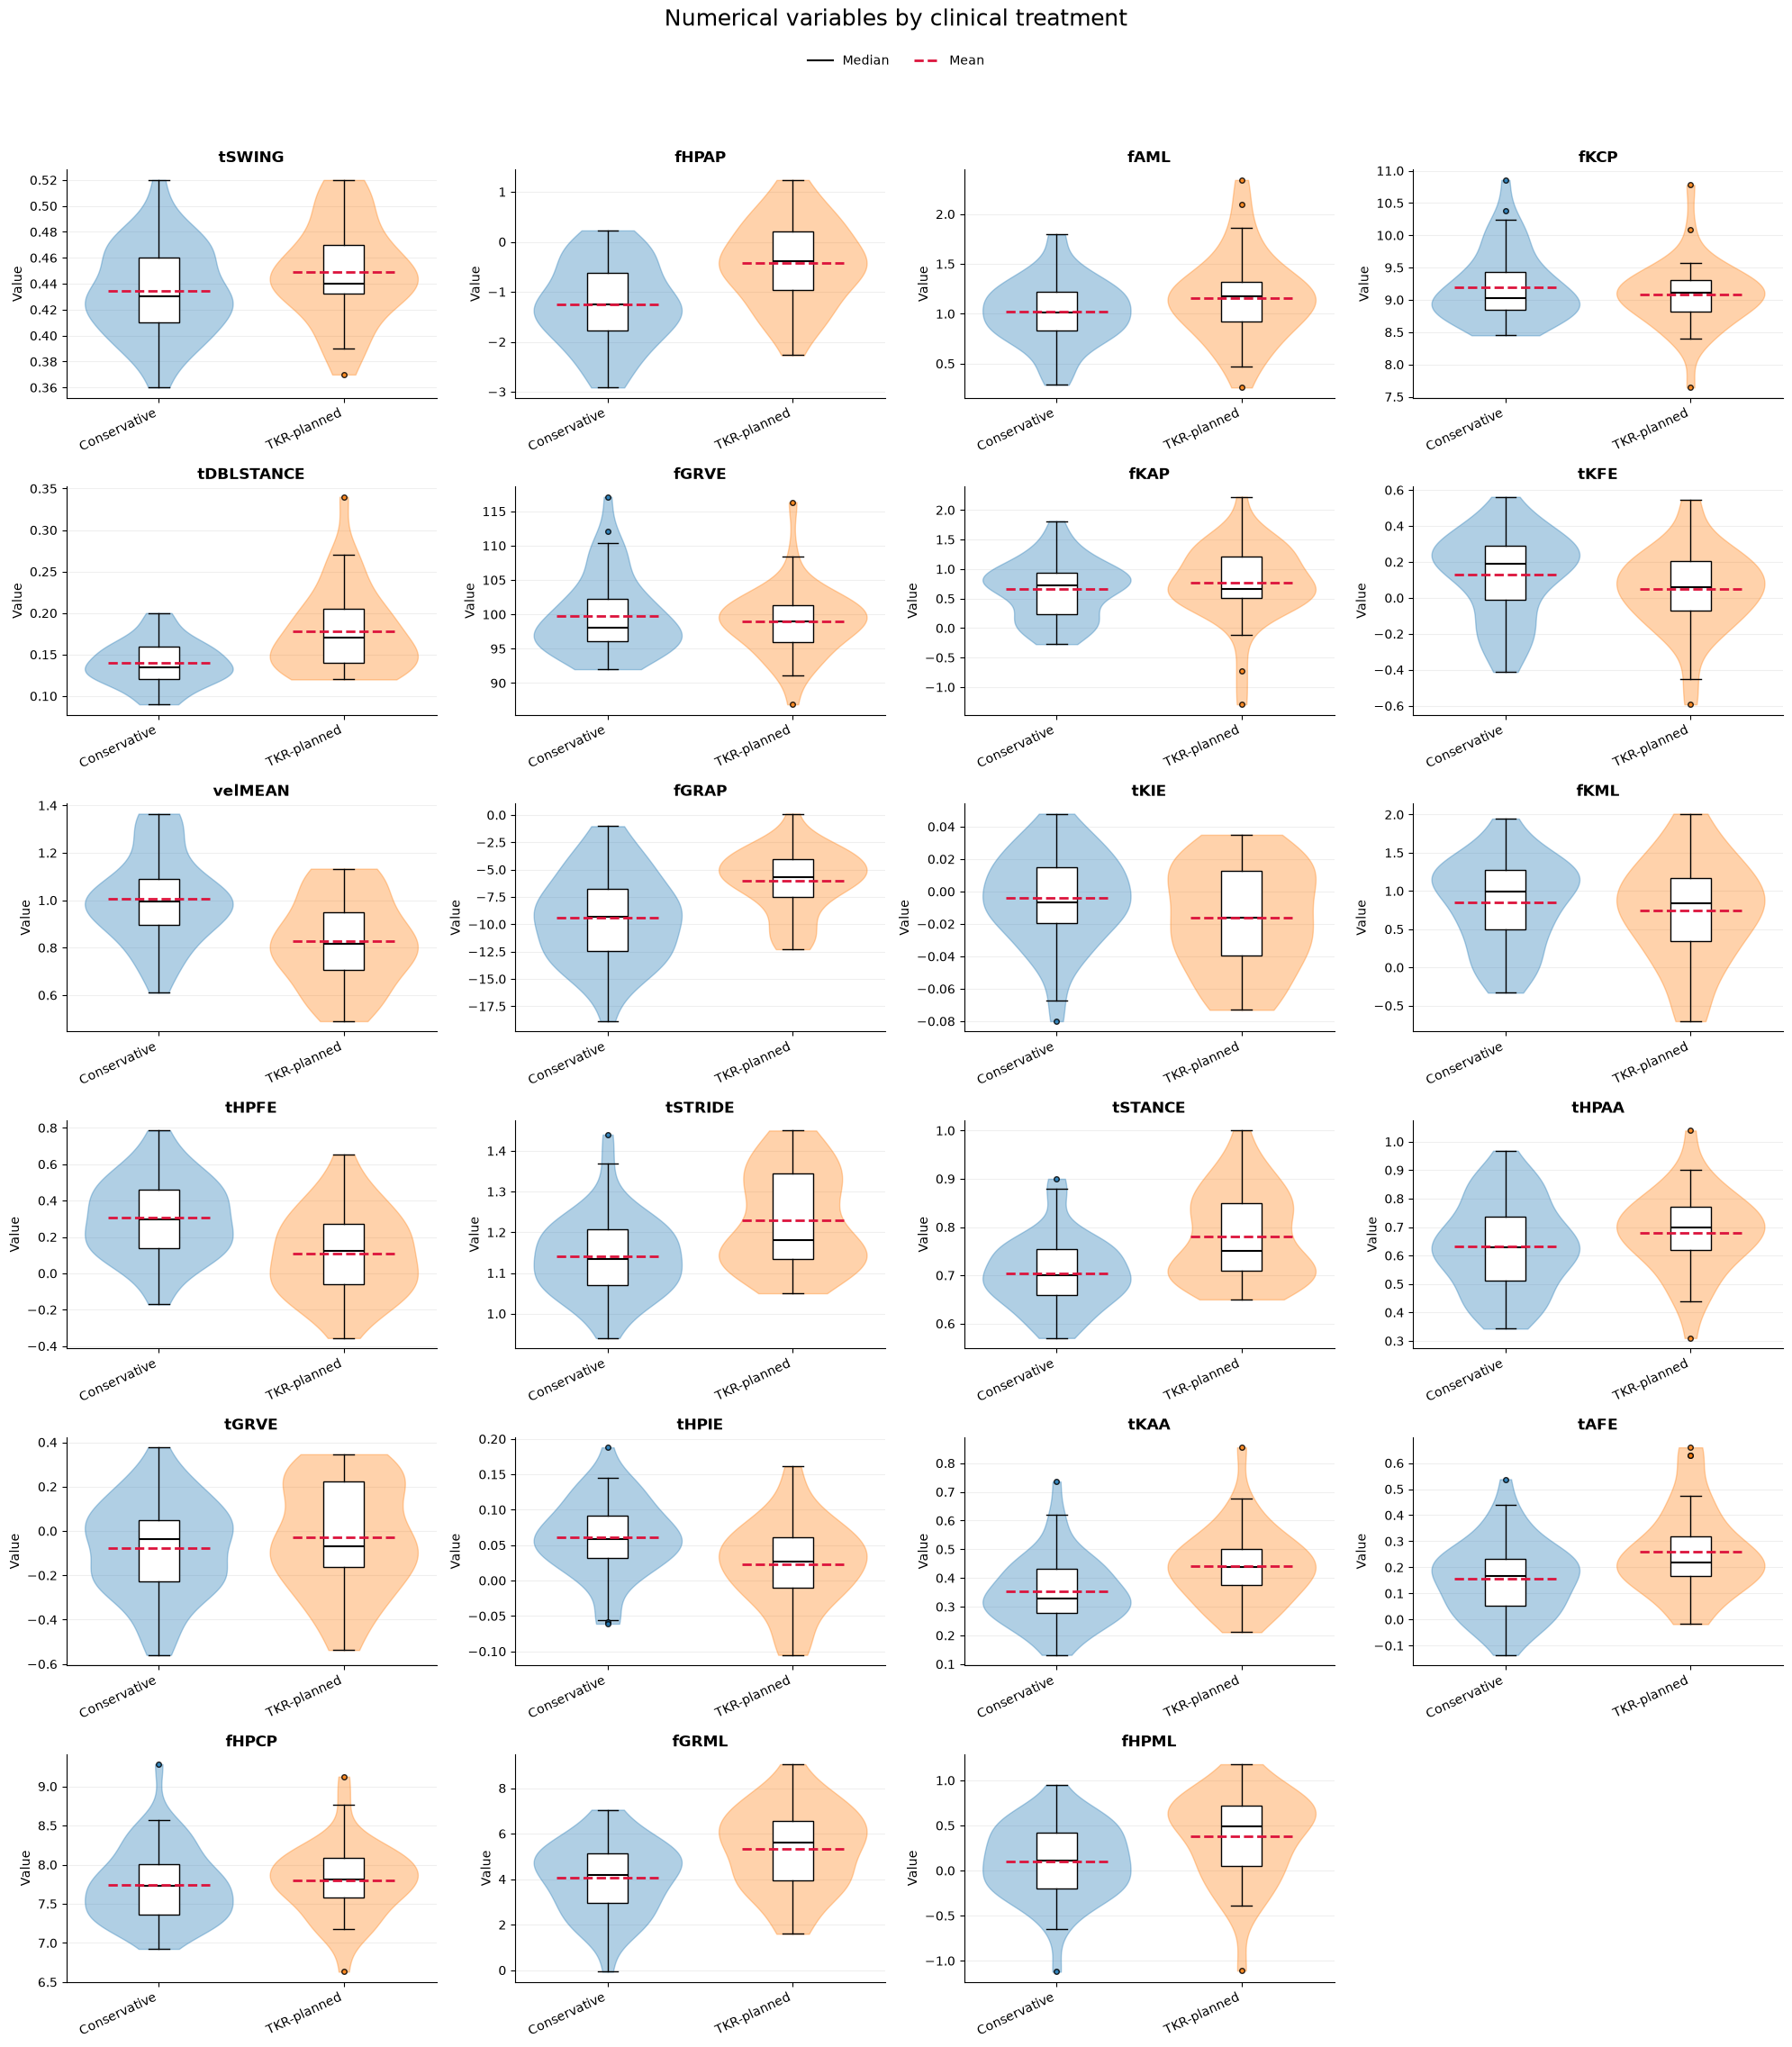

In [29]:
from matplotlib.lines import Line2D

treatments = list(df["Clinical Treatment"].dropna().unique())
colors = plt.get_cmap("tab10")(np.arange(len(treatments)) % 10)
ncols = 4
nrows = int(np.ceil(len(numerical_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), squeeze=False)

for ax, col in zip(axes.flat, numerical_cols):
    for position, (treatment, color) in enumerate(zip(treatments, colors), start=1):
        values = df.loc[df["Clinical Treatment"] == treatment, col].dropna().to_numpy()
        values = values[np.isfinite(values)]
        if len(values) == 0:
            continue
        violin = ax.violinplot(
            [values], positions=[position], widths=0.8,
            showmeans=False, showmedians=False, showextrema=False,
        )
        for body in violin["bodies"]:
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_alpha(0.35)
        ax.boxplot(
            [values], positions=[position], widths=0.22,
            patch_artist=True, showfliers=True, manage_ticks=False,
            flierprops=dict(marker="o", markerfacecolor=color,
                            markeredgecolor="black", markersize=4, alpha=0.85),
            boxprops=dict(facecolor="white", edgecolor="black"),
            medianprops=dict(color="black", linewidth=1.5),
            zorder=3,
        )
        ax.hlines(values.mean(), position - 0.275, position + 0.275,
                  color="crimson", linestyle="--", linewidth=2, zorder=4)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xticks(range(1, len(treatments) + 1))
    ax.set_xticklabels([str(t) for t in treatments], rotation=25, ha="right")
    ax.set_xlim(0.5, len(treatments) + 0.5)
    ax.set_ylabel("Value")
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes.flat[len(numerical_cols):]:
    ax.remove()

fig.suptitle("Numerical variables by clinical treatment", fontsize=18, y=0.995)
fig.legend(handles=[
    Line2D([], [], color="black", linewidth=1.5, label="Median"),
    Line2D([], [], color="crimson", linestyle="--", linewidth=2, label="Mean"),
], loc="upper center", bbox_to_anchor=(0.5, 0.978), ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()